In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader , Dataset
import torch.nn as nn
import math
import numpy as np
import pandas as pd
from collections import Counter

In [2]:
path = "/content/hindi_english_parallel.csv"

In [3]:
df = pd.read_csv(path, encoding='utf-8', on_bad_lines='warn', encoding_errors='replace')
df.head()

,�ा है फिर तुम देखते हो कि बूँदियां उसके दरमियान से निकल पड़ती हैं फिर जब ख़ुदा उन्हें अपने बन्दों में से जिस पर चहता है बरसा देता है तो वह लोग खुशियाँ माानने लगते हैं,"Allah is He Who sendeth the winds so that they raise clouds, and spreadeth them along the sky as pleaseth Him, and causeth them to break and thou seest the rain downpouring from within them. And when He maketh it to fall on whom He will of His bondmen, lo! they rejoice;"
0,अगरचे ये लोग उन पर (बाराने रहमत) नाज़िल होने स...,"Though before that, even before it was sent do..."
1,ग़रज़ ख़ुदा की रहमत के आसार की तरफ देखो तो कि ...,"Look, therefore, at the prints of Allah 's mer..."
2,और अगर हम (खेती की नुकसान देह) हवा भेजें फिर ल...,And if We sent a wind and they beheld it yello...
3,(ऐ रसूल) तुम तो (अपनी) आवाज़ न मुर्दो ही को सु...,For verily thou (Muhammad) canst not make the ...
4,और न तुम अंधों को उनकी गुमराही से (फेरकर) राह ...,Nor canst thou guide the blind out of their er...


In [4]:
# Clean up corrupted columns first
df.columns = df.columns.str.strip()  # Remove whitespace

# Check current columns
print("Current columns:", df.columns.tolist())

# Rename using partial matching or position (since encoding broke full names)
df = df.rename(columns={
    df.columns[0]: "hindi",      # First column → Hindi
    df.columns[1]: "english"     # Second column → English
})

# Verify
print("New columns:", df.columns.tolist())
print(df[['hindi', 'english']].head())


Current columns: ['�ा है फिर तुम देखते हो कि बूँदियां उसके दरमियान से निकल पड़ती हैं फिर जब ख़ुदा उन्हें अपने बन्दों में से जिस पर चहता है बरसा देता है तो वह लोग खुशियाँ माानने लगते हैं', 'Allah is He Who sendeth the winds so that they raise clouds, and spreadeth them along the sky as pleaseth Him, and causeth them to break and thou seest the rain downpouring from within them. And when He maketh it to fall on whom He will of His bondmen, lo! they rejoice;']
New columns: ['hindi', 'english']
                                               hindi  \
0  अगरचे ये लोग उन पर (बाराने रहमत) नाज़िल होने स...   
1  ग़रज़ ख़ुदा की रहमत के आसार की तरफ देखो तो कि ...   
2  और अगर हम (खेती की नुकसान देह) हवा भेजें फिर ल...   
3  (ऐ रसूल) तुम तो (अपनी) आवाज़ न मुर्दो ही को सु...   
4  और न तुम अंधों को उनकी गुमराही से (फेरकर) राह ...   

                                             english  
0  Though before that, even before it was sent do...  
1  Look, therefore, at the prints of Allah 's mer...  
2 

In [111]:
df.shape
df = df[:1000000]

In [112]:
%load_ext cudf.pandas
def english_vocab_fn(english):
  ## english loop
  counter_english = {
      "<unk>":1,
      "<pad>":1,
      "<eos>":1,
      "<sos>":1
  }
  i = 0
  for row in english.agg(lambda x: x.tolist()):
    counter_english.update(Counter(row.split()))
    i+=1
  print(i,english.shape)
  # vocab
  english_vocab = {
    "<pad>":0,
    "<unk>":1,
    "<eos>":2,
    "<sos>":3
  }

  for key,value in counter_english.items():
    if key not in english_vocab and value > 0 :
      english_vocab[key] = len(english_vocab)
  print(len(english_vocab))
  return english_vocab,counter_english

def hindi_vocab_fn(hindi):
  ## english loop
  conuter_hindi = {
      "<unk>":1,
      "<pad>":1,
      "<eos>":1,
      "<sos>":1
  }
  i = 0
  for row in hindi.agg(lambda x: x.tolist()):
    conuter_hindi.update(Counter(row.split()))
    i+=1
  print(i,hindi.shape)
  # vocab
  hindi_vocab = {
    "<pad>":0,
    "<unk>":1,
    "<eos>":2,
    "<sos>":3
  }

  for key,value in conuter_hindi.items():
    if key not in hindi_vocab and value > 0 :
      hindi_vocab[key] = len(hindi_vocab)
  print(len(hindi_vocab))
  return hindi_vocab,conuter_hindi
  return hindi_vocab,counter_english


The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [113]:
%load_ext cudf.pandas
hindi,english = df["hindi"],df["english"]
print(hindi.shape,english.shape)
english = english.dropna(how="any",axis=0)
hindi = hindi.dropna(how="any",axis=0)
english_vocab , english_counter= english_vocab_fn(english)
hindi_vocab , hindi_counter = hindi_vocab_fn(hindi)

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas
(10000,) (10000,)
10000 (10000,)
15440
10000 (10000,)
17385


In [114]:
from datasets import Dataset, DatasetDict

In [115]:
df = df.dropna(how="any",axis=0)

In [116]:
df.isna().sum()

,0
hindi,0
english,0


In [117]:
from sklearn.model_selection import train_test_split

In [118]:
# train and test split
train , test = train_test_split(df,test_size = 0.2,random_state = 42)
train , val = train_test_split(train,test_size=0.2,random_state=42)

In [119]:
train.shape , test.shape , val.shape

((6400, 2), (2000, 2), (1600, 2))

In [120]:
# Convert each DataFrame to a Dataset object
train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(val)
test_dataset = Dataset.from_pandas(test)

# Combine into a DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    "test":test_dataset
})
dataset_dict = dataset_dict.remove_columns('__index_level_0__')

In [121]:
train , test , val = (
    dataset_dict["train"],
    dataset_dict["test"],
    dataset_dict["validation"]
)

In [122]:
train.shape , test.shape , val.shape

((6400, 2), (2000, 2), (1600, 2))

In [123]:
def tokenize(text,en_vocab,hi_vocab,lower,eos_token,sos_token):
  en_tokens = [word for word in text["english"].split()]
  hi_tokens = [word for word in text["hindi"].split()]
  ## print(en_tokens,hi_tokens)
  if lower:
    en_tokens = [word.lower() for word in en_tokens]
    hi_tokens = [word.lower() for word in hi_tokens]
  en_tokens = [sos_token] + en_tokens + [eos_token]
  hi_tokens = [sos_token] + hi_tokens + [eos_token]
  en_tokenize = [en_vocab[word] if word in en_vocab else en_vocab["<unk>"] for word in en_tokens]
  hi_tokenize = [hi_vocab[word] if word in hi_vocab else hi_vocab["<unk>"] for word in hi_tokens]
  return {"english_token":en_tokens , "hindi_tokens":hi_tokens , "english_indices":torch.tensor(en_tokenize),"hindi_indices":torch.tensor(hi_tokenize)}

In [124]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_vocab": english_vocab,
    "hi_vocab": hindi_vocab,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train = train.map(tokenize, fn_kwargs=fn_kwargs)
val = val.map(tokenize, fn_kwargs=fn_kwargs)
test = test.map(tokenize, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [125]:
data_type = "torch"
format_columns = ["english_indices", "hindi_indices"]

train = train.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)
test = test.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)
val = val.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

In [126]:
import torch.nn as nn
from torch.utils.data import DataLoader , Dataset

In [127]:
def get_collate_fn(pad_index, max_seq_len=100):
    def collate_fn(batch):
        batch_en_ids = [example["english_indices"] for example in batch]
        batch_hi_ids = [example["hindi_indices"] for example in batch]

        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index, batch_first=True)
        batch_hi_ids = nn.utils.rnn.pad_sequence(batch_hi_ids, padding_value=pad_index, batch_first=True)

        # Truncate/Pad to exactly 100
        if batch_en_ids.size(1) > max_seq_len:
            batch_en_ids = batch_en_ids[:, :max_seq_len]
        else:
            pad_width = max_seq_len - batch_en_ids.size(1)
            batch_en_ids = F.pad(batch_en_ids, (0, pad_width), value=pad_index)

        if batch_hi_ids.size(1) > max_seq_len:
            batch_hi_ids = batch_hi_ids[:, :max_seq_len]
        else:
            pad_width = max_seq_len - batch_hi_ids.size(1)
            batch_hi_ids = F.pad(batch_hi_ids, (0, pad_width), value=pad_index)

        batch = {
            "english_indices": batch_en_ids,
            "hindi_indices": batch_hi_ids
        }
        return batch
    return collate_fn

In [128]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [129]:
batch_size = 16
pad_index = english_vocab["<pad>"]
train_data_loader = get_data_loader(train, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(val, batch_size, pad_index)
test_data_loader = get_data_loader(test, batch_size, pad_index)

In [130]:

for batch in train_data_loader:
  print(batch["english_indices"].shape)

torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size([16, 100])
torch.Size

In [131]:
batch["english_indices"].shape

torch.Size([16, 100])

### transformer Building

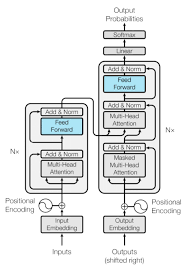

In [132]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import math

In [133]:
batch_size = 128
english_vocab_size = len(english_vocab)
hindi_vocab_size = len(hindi_vocab)
embedding_dim = 512
max_seq_len = 297
heads = 8
d_k = 16
mask = 1

In [134]:
size = 0
for batch in train_data_loader:
  size = max(size,batch["english_indices"].shape[1])

In [135]:
size

100

In [136]:
english_vocab_size , hindi_vocab_size

(15440, 17385)

In [137]:
class InputEmbedding(nn.Module):
  def __init__(self,vocab_size,embedding_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size,embedding_dim)
  def forward(self,X):
    return self.embedding(X)

In [138]:
class PositionalEncoding(nn.Module):
  def __init__(self,vocab_size,embedding_dim,max_seq_len):
    super().__init__()
    self.max_seq_len = max_seq_len
    self.d_k = embedding_dim
    pe = torch.zeros(max_seq_len,embedding_dim)
    #print(pe.shape)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * (-math.log(1000.0)/self.d_k))
    position = torch.arange(0,max_seq_len,dtype=torch.float).unsqueeze(1)
    pe[:,0::2] = torch.sin(position*div)
    pe[:,1::2] =  torch.cos(position*div)
    #print(pe.shape)
    pe = pe.unsqueeze(0) # to convert to batch
    self.register_buffer("pe",pe)
    #print(pe.shape)

  def forward(self,X):
    return X + (self.pe[:,:X.size(1),:]).requires_grad_(False)

In [139]:
import torch.nn.functional as F

In [162]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.heads = 16
        self.N = 10
        self.C = 10
        self.head_dim = embedding_dim // self.heads
        self.Q = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.K = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.V = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.linear_fc = nn.Linear(embedding_dim, embedding_dim)

    def feature_map(self, x):
        return torch.clamp(F.elu(x) + 1, min=0, max=10)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        q_ = self.feature_map(self.Q(x)).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1,2)
        k_ = self.feature_map(self.K(x)).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1,2)
        v_ = self.V(x).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1,2)
        S_ = []
        S = torch.zeros(batch_size, self.heads, self.head_dim, self.head_dim, device=x.device)
        for c in range(self.C):
            i, j = c*self.C, min((c+1)*self.C, seq_len)
            k_i = k_[:,:,i:j,:]
            v_i = v_[:,:,i:j,:]
            kv = torch.matmul(k_i.transpose(-2,-1), v_i)
            S = S + 0.1*kv
            S_.append(S.clone())

        O = torch.zeros(batch_size, self.heads, seq_len, self.head_dim, device=x.device)
        for c in range(self.C):
            i, j = c*self.C, min((c+1)*self.C, seq_len)
            q_i = q_[:,:,i:j,:]
            prev_state = S_[c-1] if c > 0 else torch.zeros_like(S)
            O[:,:,i:j,:] = torch.matmul(q_i, prev_state)

        out = O.transpose(1,2).contiguous().view(batch_size, seq_len, -1)
        return self.linear_fc(out)


In [141]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))

  def forward(self,X):
      mean = X.mean(dim=-1,keepdim=True)
      std = X.std(dim=-1,keepdim=True)
      #print("In layer norm")
      return (self.alpha * ((X - mean)/(std + self.eps)) + self.beta)

In [142]:
class FeedForwardNetwork(nn.Module):
  def __init__(self,embedding_dim):
    super().__init__()
    self.layer_1 = nn.Linear(embedding_dim,2048)
    self.layer_2 = nn.Linear(2048,embedding_dim)

  def forward(self,X):
    #print("in feed forward")
    return self.layer_2(torch.relu(self.layer_1(X)))

In [143]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    #print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm

In [163]:

class EncoderBlock(nn.Module):
  def __init__(self,self_attention:MultiHeadAttention,feed_forward:FeedForwardNetwork):
    super().__init__()
    self.attention_block = self_attention
    self.feed_forward_block = feed_forward
    self.residual_block = nn.ModuleList([ResidualBlock() for _ in range(2)])
  def forward(self,X):
    #print("In encoder block")
    X = self.residual_block[0](X,lambda x: self.attention_block(X))
    #print("Completed residual 1")
    X = self.residual_block[1](X,lambda x: self.feed_forward_block(X))
    #print("completed residual 2")
    return X

In [164]:
class Encoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.norm = LayerNorm()

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        #print("encoder Completed")
        return self.norm(x)

In [165]:
class MaskMultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, heads):
        super().__init__()
        assert embedding_dim % heads == 0
        self.heads = heads
        self.head_dim = embedding_dim // heads
        self.C = 10  # chunk size
        self.Q = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.K = nn.Linear(embedding_dim, embedding_dim, bias=False)
        self.V = nn.Linear(embedding_dim, embedding_dim, bias=False)

    def feature_map(self, x):
        return torch.clamp(F.elu(x) + 1, min=0, max=10)

    def forward(self, X):  # No mask needed - causal by construction
        #print("Masked Attention")
        batch_size, seq_len, embedding_dim = X.size()
        q = self.feature_map(self.Q(X)).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1,2)
        k = self.feature_map(self.K(X)).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1,2)
        v = self.V(X).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1,2)
        S_ = []
        S = torch.zeros(batch_size, self.heads, self.head_dim, self.head_dim, device=X.device)
        for c in range(self.C):
            i, j = c*self.C, min((c+1)*self.C, seq_len)
            k_i = k[:,:,i:j,:]
            v_i = v[:,:,i:j,:]
            kv = torch.matmul(k_i.transpose(-2,-1), v_i)
            S += 0.1*kv
            S_.append(S.clone())

        O = torch.zeros(batch_size, self.heads, seq_len, self.head_dim, device=X.device)
        for c in range(self.C):
            i, j = c*self.C, min((c+1)*self.C, seq_len)
            q_i = q[:,:,i:j,:]
            prev_state = S_[c-1] if c > 0 else torch.zeros_like(S)
            O[:,:,i:j,:] = torch.matmul(q_i, prev_state)

        return O.transpose(1,2).contiguous().view(batch_size, seq_len, embedding_dim)


In [166]:
class CrossAttention(nn.Module):
    def __init__(self, embedding_dim, heads):
        super().__init__()
        self.d_k = embedding_dim
        assert embedding_dim % heads == 0
        self.heads = heads
        self.C = 10  # chunk size
        self.head_dim = embedding_dim // heads
        self.Q = nn.Linear(self.d_k, self.d_k)
        self.K = nn.Linear(self.d_k, self.d_k)
        self.V = nn.Linear(self.d_k, self.d_k)

    def feature_map(self, x):
        return torch.clamp(F.elu(x) + 1, min=0, max=10)

    def forward(self, encoder_x, decoder_x):
        batch_size, seq_len, _ = encoder_x.size()
        _, dec_seq_len, _ = decoder_x.size()

        q = self.Q(decoder_x).view(batch_size, dec_seq_len, self.heads, self.head_dim).transpose(1, 2)
        k = self.K(encoder_x).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1, 2)
        v = self.V(encoder_x).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1, 2)

        S = torch.zeros(batch_size, self.heads, self.head_dim, self.head_dim, device=encoder_x.device)
        S_list = []

        for c in range(self.C):
            i, j = c * self.C, min((c + 1) * self.C, seq_len)
            k_chunk = k[:, :, i:j, :]
            v_chunk = v[:, :, i:j, :]

            kv_chunk = torch.matmul(k_chunk.transpose(-2, -1), v_chunk)
            S = S + 0.1*kv_chunk
            S_list.append(S.clone())

        O = torch.zeros(batch_size, self.heads, seq_len, self.head_dim, device=encoder_x.device)
        for c in range(self.C):
            i, j = c * self.C, min((c + 1) * self.C, seq_len)
            q_chunk = q[:, :, :min(dec_seq_len, j), :]

            prev_S = S_list[c - 1] if c > 0 else torch.zeros_like(S)
            O[:, :, i:j, :] = torch.matmul(q_chunk[:, :, i:j, :], prev_S).clamp(min=-10.0, max=10.0)

        out = O.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)
        return out


In [167]:
class DecoderBlock(nn.Module):
  def __init__(self,masked_attention:MaskMultiHeadAttention , cross_attention:CrossAttention , feed_forward_network:FeedForwardNetwork):
    super().__init__()
    self.masked_attention = masked_attention
    self.cross_attention = cross_attention
    self.feed_forward = feed_forward_network
    self.residual_block = nn.ModuleList([ResidualBlock() for _ in range(3)])

  def forward(self,encoder_x,decoder_x):
    ## decoder_x = X
    ## encoder_x = from encoder
    #print("residual 1")
    decoder_x = self.residual_block[0](decoder_x,lambda x: self.masked_attention(x))
    #print("residual 2")
    X = self.residual_block[1](decoder_x,lambda x:self.cross_attention(encoder_x,x))
    #print("residual 3")
    X = self.residual_block[2](X, lambda x:self.feed_forward(x))
    return X

In [168]:
class Decoder(nn.Module):
  def __init__(self,layers:nn.ModuleList):
    super().__init__()
    self.layers = layers
    self.norm = LayerNorm()
  def forward(self,encoder_x,decoder_x):
    #print("In decoder")
    for layer in self.layers:
      X = layer(encoder_x,decoder_x)
    #print("decoder exit")
    return self.norm(X)

In [169]:
class TransformerOutputHead(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.projection_layer = nn.Linear(d_model, vocab_size)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, decoder_output_tensor):
        logits = self.projection_layer(decoder_output_tensor)
        probabilities = self.softmax(logits)

        return probabilities

In [170]:
class Transformer(nn.Module):
  def __init__(self,embedding_dim,seq_len,batch_size,mask,encoder:Encoder,decoder:Decoder,Outputlayer:TransformerOutputHead,input_embedding_layer:InputEmbedding,output_embedding_layer:InputEmbedding,input_positional_encoding:PositionalEncoding,output_positional_encoding:PositionalEncoding):
    super().__init__()
    self.embedding_dim = embedding_dim
    self.seq_len = seq_len
    self.batch_size = batch_size
    self.input_embedding = input_embedding_layer
    self.output_embedding = output_embedding_layer
    self.input_positional_layer = input_positional_encoding
    self.output_positional_layer = output_positional_encoding
    self.Encoder = encoder
    self.Decoder = decoder
    self.mask = mask
    self.OutputLayer = Outputlayer
  def forward(self,input_x,output_x):
    input_x = self.input_embedding(input_x)
    input_x = self.input_positional_layer(input_x)
    output_x = self.output_embedding(output_x)
    output_x = self.output_positional_layer(output_x)
    #print("--"*40)
    X = self.Encoder(input_x)
    #print(X.shape)
    #print("--"*40)
    X = self.Decoder(X,output_x)
    #print(X.shape)
    #print("--"*40)
    output = self.OutputLayer(X)
    #print(output.shape)
    return output

In [171]:
## Encoder
input_embedding = InputEmbedding(english_vocab_size,embedding_dim)
positional_encoding_encoder = PositionalEncoding(english_vocab_size,embedding_dim,max_seq_len)
layer_norm_encoder = LayerNorm()
residual_block_encoder = ResidualBlock()
feed_forward_network_encoder = FeedForwardNetwork(embedding_dim)
multihead_attention = MultiHeadAttention(embedding_dim)
encoder_block = EncoderBlock(multihead_attention,feed_forward_network_encoder)
encoder = Encoder(nn.ModuleList(6*[encoder_block]))

In [172]:
## Deocder
layer_norm_decoder = LayerNorm()
feed_forward_network_deocder = FeedForwardNetwork(embedding_dim)
mask_multihead_attention = MaskMultiHeadAttention(embedding_dim,heads)
cross_attention = CrossAttention(embedding_dim,heads)
output_embedding = InputEmbedding(hindi_vocab_size,embedding_dim)
positional_encoding_decoder = PositionalEncoding(hindi_vocab_size,embedding_dim,max_seq_len)
decoder_block = DecoderBlock(mask_multihead_attention,cross_attention,feed_forward_network_deocder)
decoder = Decoder(nn.ModuleList(6*[decoder_block]))
output_layer = TransformerOutputHead(embedding_dim,hindi_vocab_size)

In [173]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [174]:
## Transformer
transformer = Transformer(embedding_dim,max_seq_len,batch_size,mask,encoder,decoder,output_layer,input_embedding,output_embedding,positional_encoding_encoder,positional_encoding_decoder)
transformer.to(device)

Transformer(
  (input_embedding): InputEmbedding(
    (embedding): Embedding(15440, 512)
  )
  (output_embedding): InputEmbedding(
    (embedding): Embedding(17385, 512)
  )
  (input_positional_layer): PositionalEncoding()
  (output_positional_layer): PositionalEncoding()
  (Encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderBlock(
        (attention_block): MultiHeadAttention(
          (Q): Linear(in_features=512, out_features=512, bias=False)
          (K): Linear(in_features=512, out_features=512, bias=False)
          (V): Linear(in_features=512, out_features=512, bias=False)
          (linear_fc): Linear(in_features=512, out_features=512, bias=True)
        )
        (feed_forward_block): FeedForwardNetwork(
          (layer_1): Linear(in_features=512, out_features=2048, bias=True)
          (layer_2): Linear(in_features=2048, out_features=512, bias=True)
        )
        (residual_block): ModuleList(
          (0-1): 2 x ResidualBlock(
            (layer_norm)

In [175]:
# for i,batch in enumerate(train_data_loader):
#   print("--"*40)
#   english_src_tokens = batch['english_indices']
#   hindi_src_tokens = batch['hindi_indices']
#   # input_english = input_embedding(english_src_tokens)
#   # output_hindi = input_embedding(hindi_src_tokens)
#   # #print(input.shape)
#   # positional_output = positional_encoding_decoder(output_hindi)
#   # positional_input = positional_encoding_encoder(input_english)
#   #print(positional_input.shape)
#   output = transformer(english_src_tokens.long(),hindi_src_tokens.long())
#   print(f"index : {i} , {output.shape}")
#   break

In [176]:
optimizer = torch.optim.Adam(transformer.parameters(),lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=english_vocab["<pad>"])

In [177]:
from tqdm.notebook import tqdm
import time
import itertools
import torch
import torch.nn.functional as F

num_epochs = 5
losses = []
max_batches = 500

criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

for epoch in range(num_epochs):
    epoch_losses = []

    pbar = tqdm(itertools.islice(train_data_loader, max_batches),
               total=max_batches, desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch in pbar:
        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}
        src = batch["english_indices"].long()
        tgt = batch["hindi_indices"].long()

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        logits = transformer(src[:, :tgt_input.size(1)], tgt_input)
        loss = criterion(logits.reshape(-1, hindi_vocab_size), tgt_output.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
        optimizer.step()

        batch_loss = loss.item()
        epoch_losses.append(batch_loss)

        avg_loss = sum(epoch_losses[-10:]) / len(epoch_losses[-10:])
        pbar.set_postfix({'Loss': f'{batch_loss:.3f}', 'Avg': f'{avg_loss:.3f}'})

    if epoch_losses:
        epoch_avg = sum(epoch_losses) / len(epoch_losses)
        losses.append(epoch_avg)
        print(f'Epoch {epoch+1}: {epoch_avg:.3f}')

print(f'Final losses: {[f"{x:.3f}" for x in losses]}')


Epoch 1/5:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1: 9.749


Epoch 2/5:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2: 9.741


Epoch 3/5:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 3: 9.730


Epoch 4/5:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 4: 9.730


Epoch 5/5:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 5: 9.730
Final losses: ['9.749', '9.741', '9.730', '9.730', '9.730']


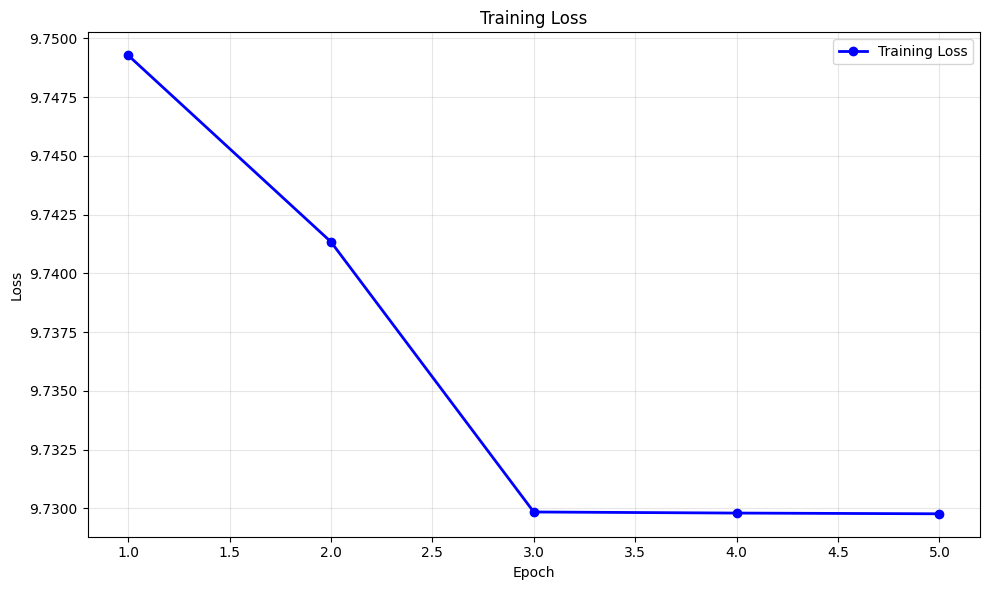

In [178]:
import matplotlib.pyplot as plt

def plot_loss(losses, epochs=None):
    """
    Plot training loss curve

    Args:
        losses: list of epoch losses
        epochs: optional list of epoch numbers
    """
    if not losses:
        print("No losses to plot")
        return

    if epochs is None:
        epochs = range(1, len(losses) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, losses, 'b-o', linewidth=2, markersize=6)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend(['Training Loss'])
    plt.tight_layout()
    plt.show()

# Usage after training:
plot_loss(losses)


In [ ]:
logits.shape

torch.Size([128, 18, 3846])

In [179]:
### how the training loop works
## english = [128,21] , hindi = [128,20]
## target_input = [128,19]
## target_output = [128,19]
## encoder = torch.Size([128, 21, 512])
## decoder = torch.Size([128, 19, 512])
## liner projection layer = torch.Size([128, 19, 3846])
## logits = torch.Size([128, 19, 3846])
##
batch["english_indices"].shape , batch["hindi_indices"].shape


(torch.Size([16, 100]), torch.Size([16, 100]))

In [180]:
tgt_input.shape , tgt_output.shape

(torch.Size([16, 99]), torch.Size([16, 99]))

In [181]:
logits.reshape(-1,hindi_vocab_size).shape , tgt_output.reshape(-1).shape

(torch.Size([1584, 17385]), torch.Size([1584]))

In [182]:
logits.shape

torch.Size([16, 99, 17385])

In [211]:
def translate(transformer, src, max_len=50):
    transformer.eval()
    batch_size = src.size(0)
    src_len = src.size(1)

    generated = torch.full((batch_size, 1), hindi_vocab["<sos>"],
                          dtype=torch.long, device=src.device)

    with torch.no_grad():
        for _ in range(max_len):
            # Pad generated to match src length exactly
            pad_len = src_len - generated.size(1)
            if pad_len > 0:
                tgt_input_pad = F.pad(generated, (0, pad_len), value=0)
            else:
                tgt_input_pad = generated[:, :src_len]

            logits = transformer(src, tgt_input_pad)
            next_token_logits = logits[:, -1, :]
            next_token = next_token_logits.argmax(dim=-1).unsqueeze(-1)  # FIXED

            generated = torch.cat([generated, next_token], dim=1)

            if next_token[0, 0].item() == hindi_vocab["<eos>"]:
                break

    return generated


In [212]:
src = batch["english_indices"][10]
original = batch["hindi_indices"][10]

In [213]:
src.unsqueeze(0).shape

torch.Size([1, 100])

In [214]:
src.shape

torch.Size([100])

In [215]:
predictions = translate(transformer,src.unsqueeze(0),50)

In [216]:
predictions.shape , original.shape

(torch.Size([1, 2]), torch.Size([100]))

In [194]:
en_vocab_indices =  {v:k for k,v in english_vocab.items()}
hi_vocab_indices = {v:k for k,v in hindi_vocab.items() }

In [217]:
def numerical_to_word(numerical_sentence,english,hindi):
  if english:
    output_english = [en_vocab_indices[word.item()] for word in numerical_sentence]
    return output_english
  if hindi:
    output_hindi = [hi_vocab_indices[word.item()] for word in numerical_sentence]
    return output_hindi

In [218]:
print(numerical_to_word(predictions.squeeze(0),0,1))
print(numerical_to_word(original,0,1))

['<sos>', '<eos>']
['<sos>', 'और', '(हैरान', 'होकर)', 'कहेगें', 'हाए', 'अफसोस', 'हम', 'तो', 'पहले', 'सो', 'रहे', 'थे', 'हमें', 'ख्वाबगाह', 'से', 'किसने', 'उठाया', '(जवाब', 'आएगा)', 'कि', 'ये', 'वही', '(क़यामत', 'का)', 'दिन', 'है', 'जिसका', 'खुदा', 'ने', '(भी)', 'वायदा', 'किया', 'था', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


### Just Completed but later i will train for some epoch then show the outptut the main training and inference pipeline is ready